In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import data_analysis.mea_analysis as mea
from pathlib import Path

In [2]:
BRW_BASE_FOLDER = Path("/media/ferdinand-forberger/RawDataBackUp")
MAIN_FOLDER = Path("/media/ferdinand-forberger/Seagate Portable Drive")
GRAPH_METRICS_PATH = MAIN_FOLDER / "graph_metrics.xlsx"



df_overview = mea.get_overview(MAIN_FOLDER)
df_overview = df_overview[df_overview["sles_saved"]==True]
df_overview.reset_index(inplace=True, drop=True)
df_overview["image_path"]= df_overview["folder_path"].astype(str) + "/org_image.png"
df_overview["mask_path"] = df_overview["folder_path"].astype(str) + "/mask.png"

#get metadata file to have info about which slice belongs to which group
df_metadata = pd.read_excel("/media/ferdinand-forberger/RawDataBackUp/meta_data_file.xlsx")
df_metadata["folder"] = df_metadata["animal_number"].astype(str) + "_" + df_metadata["slice_number"].astype(str)
df_overview = pd.merge(df_overview, df_metadata, left_on="folder", right_on="folder", how="left")
df_overview["sttc_path"] = df_overview["folder_path"] / "sttc.npy"

In [3]:
df_tumor = df_overview[df_overview["group"]=="Tumor"]
df_sham = df_overview[df_overview["group"]=="Sham"]

In [4]:
alinged_ampls_maps = np.load("data/aligned_ampl_maps.npy")
algined_freq_maps = np.load("data/aligned_freq_maps.npy")
aligned_onset_maps = np.load("data/aligned_origins_maps.npy")

global_freq_max = np.nanmax(algined_freq_maps)
global_ampl_max = np.nanmax(alinged_ampls_maps)
global_onset_max = np.nanmax(aligned_onset_maps)

In [6]:
normalized_onset_maps = aligned_onset_maps / np.nansum(aligned_onset_maps, axis=(1, 2), keepdims=True)

In [7]:
median_tumor_ampl = np.nanmedian(alinged_ampls_maps[df_tumor.index,:,:], axis=0)
median_tumor_freq = np.nanmedian(algined_freq_maps[df_tumor.index,:,:], axis=0)
assert np.all(median_tumor_freq[~np.isnan(median_tumor_freq)] <= global_freq_max), f"\
    {np.max(median_tumor_freq[~np.isnan(median_tumor_freq)]), global_freq_max}"


median_sham_ampl = np.nanmedian(alinged_ampls_maps[df_sham.index,:,:], axis=0)
median_sham_freq = np.nanmedian(algined_freq_maps[df_sham.index,:,:], axis=0)

median_onset_map_tumor = np.nanmedian(normalized_onset_maps[df_tumor.index,:,:], axis=0)
median_onset_map_sham = np.nanmedian(normalized_onset_maps[df_sham.index,:,:], axis=0)

/tmp/ipykernel_7515/4245393145.py:1: RuntimeWarning: All-NaN slice encountered
  median_tumor_ampl = np.nanmedian(alinged_ampls_maps[df_tumor.index,:,:], axis=0)
/tmp/ipykernel_7515/4245393145.py:2: RuntimeWarning: All-NaN slice encountered
  median_tumor_freq = np.nanmedian(algined_freq_maps[df_tumor.index,:,:], axis=0)
/tmp/ipykernel_7515/4245393145.py:7: RuntimeWarning: All-NaN slice encountered
  median_sham_ampl = np.nanmedian(alinged_ampls_maps[df_sham.index,:,:], axis=0)
/tmp/ipykernel_7515/4245393145.py:8: RuntimeWarning: All-NaN slice encountered
  median_sham_freq = np.nanmedian(algined_freq_maps[df_sham.index,:,:], axis=0)
/tmp/ipykernel_7515/4245393145.py:10: RuntimeWarning: All-NaN slice encountered
  median_onset_map_tumor = np.nanmedian(normalized_onset_maps[df_tumor.index,:,:], axis=0)
/tmp/ipykernel_7515/4245393145.py:11: RuntimeWarning: All-NaN slice encountered
  median_onset_map_sham = np.nanmedian(normalized_onset_maps[df_sham.index,:,:], axis=0)


In [8]:
np.nanmax(median_tumor_freq), np.nanmax(median_sham_freq)

(np.float64(20.006666666666668), np.float64(18.956666666666667))

In [9]:
background_img_path = "/media/ferdinand-forberger/RawDataBackUp/8606_1/slice_cut.png"
background_img = plt.imread(background_img_path)

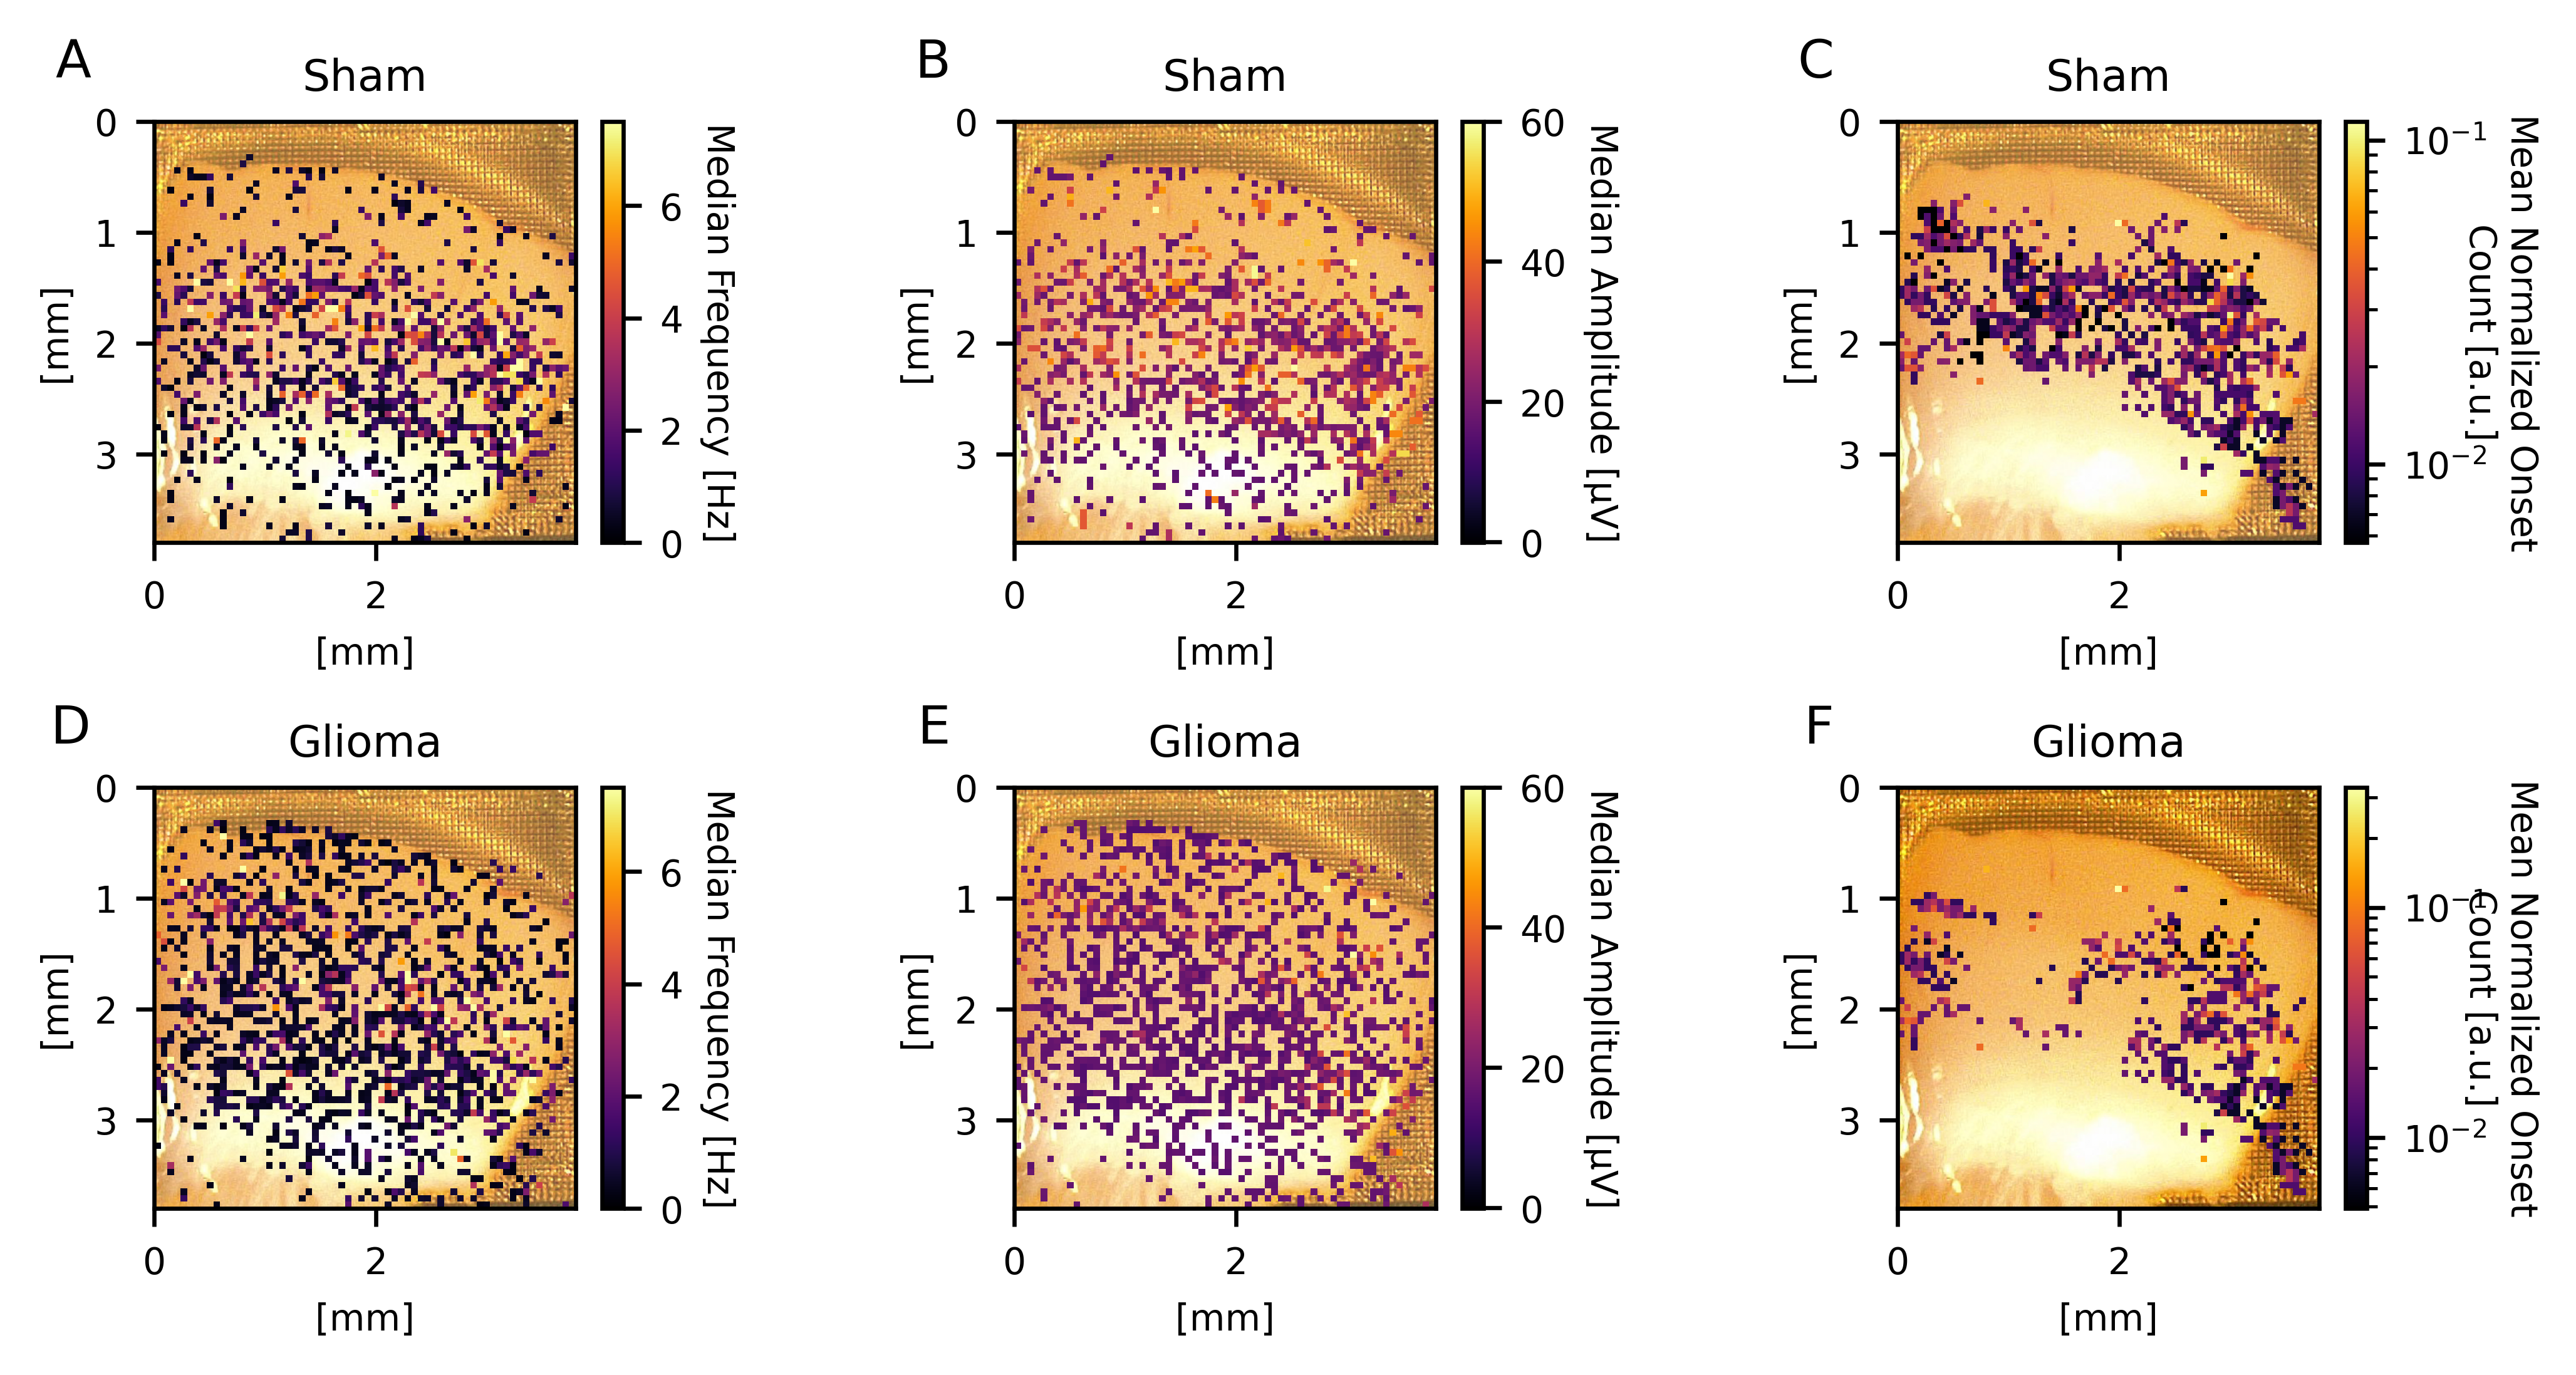

In [15]:
from data_analysis.plotting import get_c_map_colors

colors = get_c_map_colors(5)
plt.rcParams.update({'font.size': 7})
cm = 1/2.54
fig, axs = plt.subplots(nrows=2, 
                        ncols=3, 
                        figsize=(18*cm, 9*cm),
                        dpi=600, layout="constrained")
vmin_frq = 0
vmax_frq = 7.5
vmin_ampl = 60
vmax_ampl = 0
axs[0,0].imshow(background_img, extent=[0, 3.8, 3.8, 0], alpha=0.8,zorder=0)
axs[0,1].imshow(background_img, extent=[0, 3.8, 3.8, 0], alpha=0.8,zorder=0)
axs[0,2].imshow(background_img, extent=[0, 3.8, 3.8, 0], alpha=0.8,zorder=0)

axs[1,0].imshow(background_img, extent=[0, 3.8, 3.8, 0], alpha=0.8,zorder=0)
axs[1,1].imshow(background_img, extent=[0, 3.8, 3.8, 0], alpha=0.8,zorder=0)
axs[1,2].imshow(background_img, extent=[0, 3.8, 3.8, 0], alpha=0.8,zorder=0)

axs[0,0].set_title("Sham")
axs[0,1].set_title("Sham")
axs[0,2].set_title("Sham")
im0 = axs[0,0].imshow(median_sham_freq, 
                      cmap="inferno", 
                      #norm="log", 
                      vmin=vmin_frq, 
                      vmax=vmax_frq,
                      extent=[0, 3.8, 3.8, 0])
cbar = fig.colorbar(im0, 
                    ax=axs[0,0], 
                    fraction=0.046, 
                    pad=0.04)
cbar.set_label('Median Frequency [Hz]', rotation=270, labelpad=10)


im1 = axs[0,1].imshow(median_sham_ampl, 
                      cmap="inferno", 
                      vmin=vmin_ampl, 
                      vmax=vmax_ampl, 
                      extent=[0, 3.8, 3.8, 0])
cbar = fig.colorbar(im1, 
                    ax=axs[0,1], 
                    fraction=0.046, 
                    pad=0.04)
cbar.set_label('Median Amplitude [µV]', rotation=270, labelpad=10)

im2 = axs[0,2].imshow(median_onset_map_sham, norm="log", cmap="inferno", extent=[0, 3.8, 3.8, 0], zorder=1)
cbar = fig.colorbar(im2, 
                    ax=axs[0,2], 
                    fraction=0.046, 
                    pad=0.04)
cbar.set_label('Mean Normalized Onset\nCount [a.u.]', rotation=270, labelpad=10)

axs[1,0].set_title("Glioma")
axs[1,1].set_title("Glioma")
axs[1,2].set_title("Glioma")
im6 = axs[0,2].imshow(median_onset_map_tumor, norm="log", cmap="inferno", extent=[0, 3.8, 3.8, 0])
axs[1,2].imshow(background_img, extent=[0, 3.8, 3.8, 0], alpha=0.8)



im3 = axs[1,0].imshow(median_tumor_freq, 
                      cmap="inferno", 
                      #norm="log", 
                      extent=[0, 3.8, 3.8, 0],
                      vmin = vmin_frq,
                      vmax = vmax_frq)
cbar = fig.colorbar(im3, 
                    ax=axs[1,0], 
                    fraction=0.046, 
                    pad=0.04)
cbar.set_label('Median Frequency [Hz]', rotation=270, labelpad=10)

im4 = axs[1,1].imshow(median_tumor_ampl, 
                      cmap="inferno",
                      vmin=vmin_ampl, 
                      vmax=vmax_ampl, 
                      extent=[0, 3.8, 3.8, 0])

cbar = fig.colorbar(im4, 
                    ax=axs[1,1], 
                    fraction=0.046, 
                    pad=0.04)
cbar.set_label('Median Amplitude [µV]', rotation=270, labelpad=10)

im5 = axs[1,2].imshow(median_onset_map_tumor, norm="log", cmap="inferno", extent=[0, 3.8, 3.8, 0])

cbar = fig.colorbar(im5, 
                    ax=axs[1,2], 
                    fraction=0.046, 
                    pad=0.04)
cbar.set_label('Mean Normalized Onset\nCount [a.u.]', rotation=270, labelpad=10)

axes = axs.flatten()
letters = ["A", "B", "C", "D", "E", "F"]
for i, ax in enumerate(axes):
    ax.set_xlabel("[mm]")
    ax.set_ylabel("[mm]")
    ax.text(-0.15, 1.2, letters[i], transform=ax.transAxes,
            fontsize=10, va='top', ha='right')
    
plt.savefig("plots/Aligned_averages.png", dpi=600, bbox_inches="tight")
plt.show()